# Coffee and Sleep Analysis

## Research question
Does sleeping fewer hours relate to drinking more coffee?

## Hypothesis
- H0: There is no relationship between sleep hours and coffee intake.
- H1: People who sleep less tend to drink more coffee.


## 1. Import libraries and load the data


In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')

df = pd.read_csv('synthetic_coffee_health_10000.csv')
df.head()


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


## 2. Check the dataset


In [52]:
df.shape


(10000, 16)

In [54]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14  Smoking                

In [55]:
df.isna().sum()[df.isna().sum() > 0]


Health_Issues    5941
dtype: int64

Only `Health_Issues` has missing values. In this dataset, that means no issue was recorded, so we fill it with `None` and keep all rows.


In [56]:
df['Health_Issues'] = df['Health_Issues'].fillna('None')
df[['Sleep_Hours', 'Coffee_Intake', 'Sleep_Quality']].describe(include='all')


,Sleep_Hours,Coffee_Intake,Sleep_Quality
count,10000.000000,10000.000000,10000
unique,NaN,NaN,4
top,NaN,NaN,Good
freq,NaN,NaN,5637
mean,6.636220,2.509230,NaN
std,1.222055,1.450248,NaN
min,3.000000,0.000000,NaN
25%,5.800000,1.500000,NaN
50%,6.600000,2.500000,NaN
75%,7.500000,3.500000,NaN


## 3. Explore the main variables


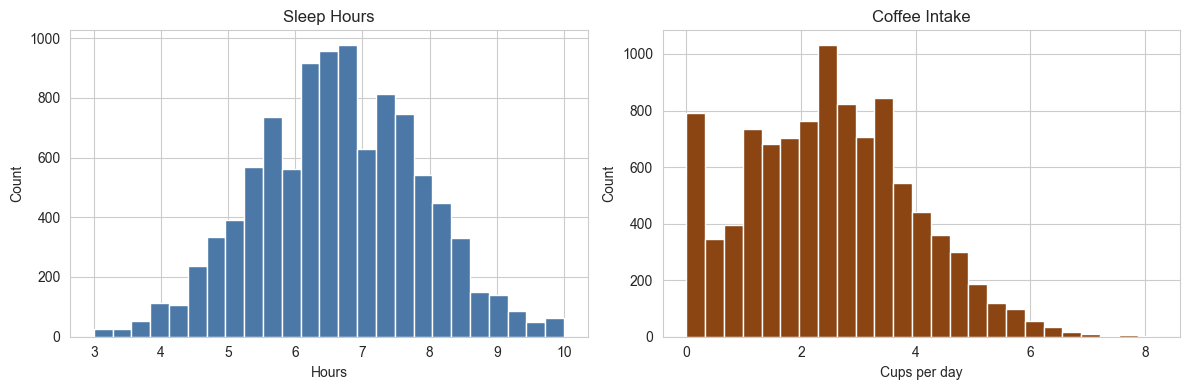

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Sleep_Hours'], bins=25, color='#4C78A8', edgecolor='white')
axes[0].set_title('Sleep Hours')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Count')

axes[1].hist(df['Coffee_Intake'], bins=25, color='#8B4513', edgecolor='white')
axes[1].set_title('Coffee Intake')
axes[1].set_xlabel('Cups per day')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


Most people are around the middle range for sleep, and most people drink a low to medium amount of coffee.


## 4. Sleep hours vs coffee intake


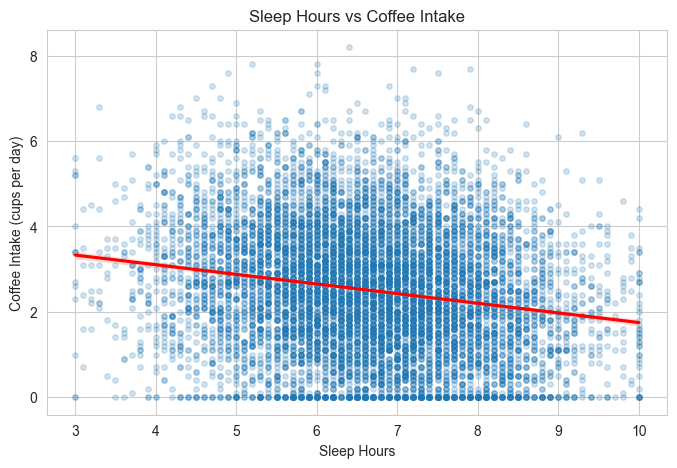

In [58]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x='Sleep_Hours',
    y='Coffee_Intake',
    scatter_kws={'alpha': 0.2, 's': 15},
    line_kws={'color': 'red'}
)
plt.title('Sleep Hours vs Coffee Intake')
plt.xlabel('Sleep Hours')
plt.ylabel('Coffee Intake (cups per day)')
plt.show()


The line slopes downward, which suggests that people who sleep more usually drink a little less coffee.


## 5. Coffee intake by sleep group

To make the pattern easier to explain, we split people into three groups.


In [59]:
def sleep_group(hours):
    if hours < 6:
        return 'Short sleep'
    if hours <= 8:
        return 'Normal sleep'
    return 'Long sleep'


df['Sleep_Group'] = df['Sleep_Hours'].apply(sleep_group)
order = ['Short sleep', 'Normal sleep', 'Long sleep']

df.groupby('Sleep_Group')['Coffee_Intake'].agg(['mean', 'median', 'count']).reindex(order).round(2)


,mean,median,count
Sleep_Group,,,
Short sleep,2.84,2.8,2878
Normal sleep,2.45,2.4,5854
Long sleep,2.04,1.9,1268


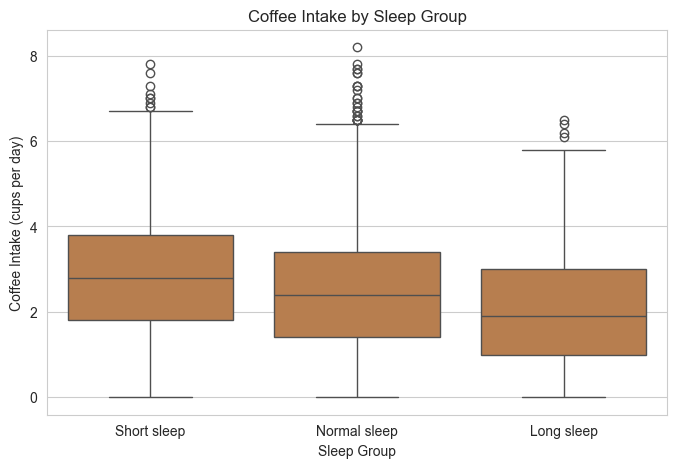

In [60]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Sleep_Group', y='Coffee_Intake', order=order, color='#C97C3D')
plt.title('Coffee Intake by Sleep Group')
plt.xlabel('Sleep Group')
plt.ylabel('Coffee Intake (cups per day)')
plt.show()


Short sleepers usually drink more coffee than long sleepers.


## 6. Correlation heatmap


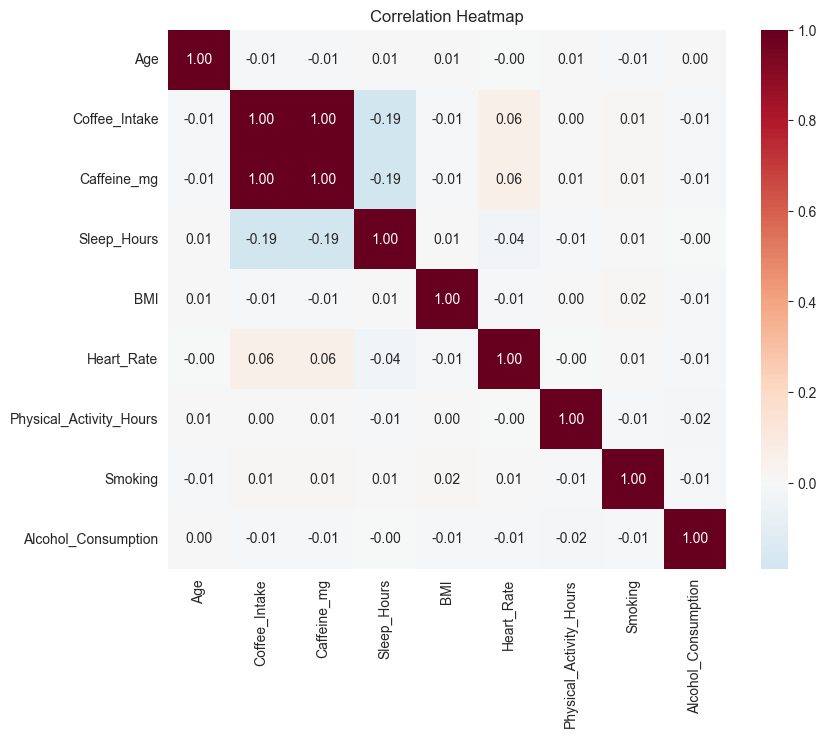

In [61]:
numeric_cols = [
    'Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI',
    'Heart_Rate', 'Physical_Activity_Hours', 'Smoking', 'Alcohol_Consumption'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


The heatmap shows that sleep hours has one of the clearest relationships with coffee intake. `Caffeine_mg` is highest because it is basically measuring the same thing as coffee intake.


## 7. Sleep quality and coffee intake


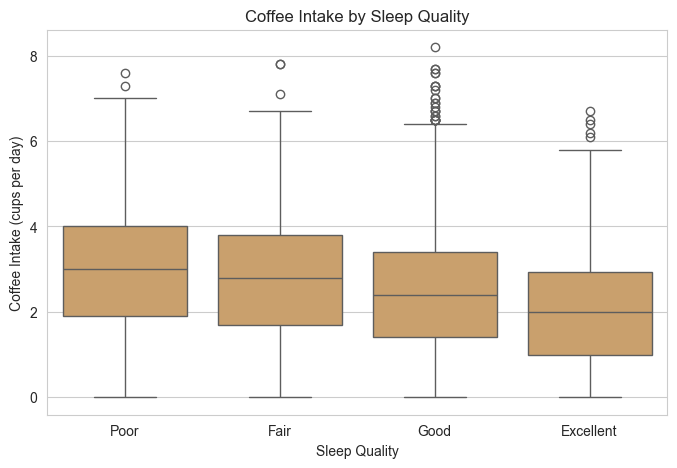

In [62]:
sleep_quality_order = ['Poor', 'Fair', 'Good', 'Excellent']

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Sleep_Quality', y='Coffee_Intake', order=sleep_quality_order, color='#D8A25E')
plt.title('Coffee Intake by Sleep Quality')
plt.xlabel('Sleep Quality')
plt.ylabel('Coffee Intake (cups per day)')
plt.show()


In [63]:
quality_groups = [df.loc[df['Sleep_Quality'] == quality, 'Coffee_Intake'] for quality in sleep_quality_order]
quality_f, quality_p = stats.f_oneway(*quality_groups)

pd.DataFrame({
    'F_statistic': [round(quality_f, 4)],
    'p_value': [quality_p]
})


,F_statistic,p_value
0,106.9206,3.901463e-68


People who report worse sleep quality also tend to drink more coffee.


## 8. Hypothesis testing


In [64]:
pearson_r, pearson_p = stats.pearsonr(df['Sleep_Hours'], df['Coffee_Intake'])
spearman_r, spearman_p = stats.spearmanr(df['Sleep_Hours'], df['Coffee_Intake'])

sleep_groups = [df.loc[df['Sleep_Group'] == group, 'Coffee_Intake'] for group in order]
anova_f, anova_p = stats.f_oneway(*sleep_groups)

pd.DataFrame({
    'Test': ['Pearson correlation', 'Spearman correlation', 'One-way ANOVA'],
    'Statistic': [round(pearson_r, 4), round(spearman_r, 4), round(anova_f, 4)],
    'p_value': [pearson_p, spearman_p, anova_p]
})


,Test,Statistic,p_value
0,Pearson correlation,-0.1903,3.533694e-82
1,Spearman correlation,-0.1901,5.677251e-82
2,One-way ANOVA,150.8651,2.814580e-65


In [65]:
pd.DataFrame({
    'Measure': ['r squared'],
    'Value': [round(pearson_r ** 2, 4)]
})


,Measure,Value
0,r squared,0.0362


The tests show a statistically significant negative relationship. The relationship is real, but it is not very strong.


## 9. Check important subgroups


In [66]:
gender_rows = []
for name, group in df.groupby('Gender'):
    r, p = stats.pearsonr(group['Sleep_Hours'], group['Coffee_Intake'])
    gender_rows.append({'Group': name, 'r': round(r, 3), 'p_value': p})

pd.DataFrame(gender_rows)


,Group,r,p_value
0,Female,-0.197,6.836976e-45
1,Male,-0.181,2.588559e-36
2,Other,-0.248,1.683634e-04


In [67]:
stress_rows = []
for name, group in df.groupby('Stress_Level'):
    r, p = stats.pearsonr(group['Sleep_Hours'], group['Coffee_Intake'])
    stress_rows.append({'Group': name, 'r': round(r, 3), 'p_value': p})

occupation_rows = []
for name, group in df.groupby('Occupation'):
    r, p = stats.pearsonr(group['Sleep_Hours'], group['Coffee_Intake'])
    occupation_rows.append({'Group': name, 'r': round(r, 3), 'p_value': p})

stress_df = pd.DataFrame(stress_rows)
occupation_df = pd.DataFrame(occupation_rows)

stress_df, occupation_df


(    Group      r       p_value
 0    High  0.022  4.894113e-01
 1     Low -0.144  8.351169e-34
 2  Medium -0.040  7.267789e-02,
         Group      r       p_value
 0  Healthcare -0.221  4.568253e-23
 1      Office -0.150  6.477167e-12
 2       Other -0.172  5.789876e-15
 3     Service -0.222  2.306801e-23
 4     Student -0.191  1.351092e-17)

Most subgroup results are still negative, especially across occupation groups. However, the High stress group is close to zero, so we should not claim the pattern is exactly the same in every subgroup.


## 10. Conclusion

The analysis supports the idea that people who sleep less tend to drink more coffee. The graphs and the hypothesis tests all support that overall result.

At the same time, the effect size is modest, so sleep is only one factor among many. The subgroup check also shows that the pattern is not identical in every case, especially for stress levels.
